In [ ]:
# Cell 1: Conect to Google Drive 
# mount the drive to read the data
# Change the runtime type to T4 GPU at first
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Cell 2: Set dataset paths and check files
import os
from pathlib import Path

# Google Drive path of the dataset root
DATA_ROOT = Path("/content/gdrive/MyDrive/AffectiveComputing/data/FER-2013")

# Use training_set subfolder when present; otherwise use root directly
DATA_DIR = DATA_ROOT / "training_set" if (DATA_ROOT / "training_set").exists() else DATA_ROOT
ANN_PATH = DATA_DIR / "annotations.csv"
dataset_path = str(DATA_DIR)

# Check if the directory exists
if not os.path.exists(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found. Please ensure Google Drive is mounted correctly and the path is accurate.")
else:
    print(f"Using dataset path: {dataset_path}")
    print(f"Annotations file exists: {ANN_PATH.exists()}")

Using dataset path: /content/gdrive/MyDrive/AffectiveComputing/data/FER-2013
Annotations file exists: False


In [28]:
# Cell 3: Read FER-2013 + training_set, downsample FER-2013 to 10%, combine, and split

import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def normalize_label(raw_label):
    s = str(raw_label).lower().strip()
    mapping = {
        "neutral": "neutral",
        "happy": "happy",
        "happiness": "happy",
        "0": "neutral",
        "1": "happy",
    }
    return mapping.get(s, None)


def collect_fer2013_df(root_dir):
    rows = []
    for split_name in ["train", "test"]:
        split_dir = Path(root_dir) / split_name
        if not split_dir.exists():
            continue

        for class_dir in split_dir.iterdir():
            if not class_dir.is_dir():
                continue
            label = normalize_label(class_dir.name)
            if label not in {"neutral", "happy"}:
                continue

            for img_path in class_dir.rglob("*"):
                if img_path.is_file() and img_path.suffix.lower() in valid_exts:
                    rows.append({
                        "filepath": str(img_path),
                        "label": label,
                        "source": "fer2013",
                        "split_hint": split_name,
                    })

    return pd.DataFrame(rows)


def collect_training_set_df(data_dir):
    data_dir = Path(data_dir)
    ann_path = data_dir / "annotations.csv"
    if not ann_path.exists():
        raise FileNotFoundError(f"training_set annotations.csv not found at: {ann_path}")

    df_ann = pd.read_csv(ann_path, header=None, names=["filename", "label"])
    df_ann["label"] = df_ann["label"].apply(normalize_label)
    df_ann = df_ann[df_ann["label"].isin(["neutral", "happy"])].copy()

    # Match image files in a case-insensitive way
    image_files = {
        p.name.lower(): str(p)
        for p in data_dir.iterdir()
        if p.is_file() and p.suffix.lower() in valid_exts
    }
    df_ann["filepath"] = df_ann["filename"].astype(str).str.lower().map(image_files)
    df_ann = df_ann.dropna(subset=["filepath"]).copy()

    df_ann = df_ann[["filepath", "label"]].drop_duplicates(subset=["filepath"]).reset_index(drop=True)
    df_ann["source"] = "training_set"
    return df_ann


# 1) Read FER-2013 and downsample to 10%
fer_df = collect_fer2013_df(DATA_ROOT)
if fer_df.empty:
    raise ValueError("No neutral/happy samples found in FER-2013 under train/test folders.")

fer_df = fer_df.drop_duplicates(subset=["filepath"]).reset_index(drop=True)
fer_n = max(1, int(len(fer_df) * 0.20))
fer_df_small = fer_df.sample(n=fer_n, random_state=SEED).reset_index(drop=True)

print(f"FER-2013 loaded: {len(fer_df)}")
print(f"FER-2013 downsampled to 10%: {len(fer_df_small)}")
print("FER-2013 sampled labels:", fer_df_small["label"].value_counts().to_dict())

# 2) Read training_set as the second dataset
TRAINING_SET_DIR = DATA_ROOT.parent / "training_set"
training_set_df = collect_training_set_df(TRAINING_SET_DIR)
print(f"training_set loaded: {len(training_set_df)}")
print("training_set labels:", training_set_df["label"].value_counts().to_dict())

# 3) Combine datasets
combined_df = pd.concat(
    [
        fer_df_small[["filepath", "label", "source"]],
        training_set_df[["filepath", "label", "source"]],
    ],
    ignore_index=True,
)
combined_df = combined_df.drop_duplicates(subset=["filepath"]).reset_index(drop=True)

if combined_df.empty:
    raise ValueError("Combined dataset is empty after filtering.")

print(f"Combined samples: {len(combined_df)}")
print("Combined label distribution:", combined_df["label"].value_counts().to_dict())
print("Combined source distribution:", combined_df["source"].value_counts().to_dict())

# 4) Stratified 70/15/15 split
train_df, temp_df = train_test_split(
    combined_df,
    test_size=0.30,
    random_state=SEED,
    stratify=combined_df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("Train labels:", train_df["label"].value_counts().to_dict())
print("Val labels:", val_df["label"].value_counts().to_dict())
print("Test labels:", test_df["label"].value_counts().to_dict())

FER-2013 loaded: 15187
FER-2013 downsampled to 10%: 3037
FER-2013 sampled labels: {'happy': 1779, 'neutral': 1258}
training_set loaded: 500
training_set labels: {'neutral': 250, 'happy': 250}
Combined samples: 3537
Combined label distribution: {'happy': 2029, 'neutral': 1508}
Combined source distribution: {'fer2013': 3037, 'training_set': 500}
Train: 2475 | Val: 531 | Test: 531
Train labels: {'happy': 1420, 'neutral': 1055}
Val labels: {'happy': 304, 'neutral': 227}
Test labels: {'happy': 305, 'neutral': 226}


In [ ]:
# Cell 4: Install required packages
import subprocess, sys

packages = [
    "torch", "torchvision",
    "transformers", "accelerate",
    "scikit-learn", "xgboost",
    "Pillow", "pandas",
    "matplotlib", "seaborn",
    "umap-learn",
    "kagglehub",
    "mlflow",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
print("All packages installed.")

All packages installed.


In [ ]:
# Cell 5: Imports & configuration
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from transformers import (
    CLIPModel, CLIPProcessor,
    AutoModel, AutoProcessor,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.base import clone
from xgboost import XGBClassifier

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.manifold import TSNE

# Reproducibility & paths
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MLflow setup (store runs on Google Drive)
MLFLOW_DIR = Path("/content/gdrive/MyDrive/AffectiveComputing/mlruns")
MLFLOW_DIR.mkdir(parents=True, exist_ok=True)
mlflow.set_tracking_uri(f"file:{MLFLOW_DIR}")
mlflow.set_experiment("affective_computing_binary_emotion")

print(f"Device: {DEVICE}")
print(f"Data dir exists: {DATA_DIR.exists()}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

Device : cuda
Data dir exists: True


In [ ]:
# Cell 6: Load CLIP and SigLIP2 embedding models
# Load CLIP and SigLIP2 embedding models

print("Loading CLIP (openai/clip-vit-base-patch32)...")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE).eval()
print(f"  CLIP loaded — embed dim: 512")

print("Loading SigLIP2 (google/siglip2-base-patch16-224)...")
siglip_processor = AutoProcessor.from_pretrained("google/siglip2-base-patch16-224")
siglip_model     = AutoModel.from_pretrained("google/siglip2-base-patch16-224").to(DEVICE).eval()
print(f"  SigLIP2 loaded — embed dim: 768")

Loading CLIP (openai/clip-vit-base-patch32)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  CLIP loaded — embed dim: 512
Loading SigLIP2 (google/siglip2-base-patch16-224)...


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

  SigLIP2 loaded — embed dim: 768


In [ ]:
# Cell 7: Extract CLIP and SigLIP2 embeddings for all samples in train/val/test splits
# Embedding extraction

LABEL_MAP = {"neutral": 0, "happy": 1}


def to_embedding_tensor(output_obj):
    """Convert Hugging Face model outputs to a 2D tensor [batch, dim]."""
    if torch.is_tensor(output_obj):
        return output_obj

    if hasattr(output_obj, "image_embeds") and torch.is_tensor(output_obj.image_embeds):
        return output_obj.image_embeds

    if hasattr(output_obj, "pooler_output") and torch.is_tensor(output_obj.pooler_output):
        return output_obj.pooler_output

    if hasattr(output_obj, "last_hidden_state") and torch.is_tensor(output_obj.last_hidden_state):
        # Use CLS token as fallback
        return output_obj.last_hidden_state[:, 0, :]

    if isinstance(output_obj, dict):
        for key in ["image_embeds", "pooler_output", "last_hidden_state"]:
            if key in output_obj and torch.is_tensor(output_obj[key]):
                val = output_obj[key]
                return val[:, 0, :] if key == "last_hidden_state" and val.ndim == 3 else val

    if isinstance(output_obj, (tuple, list)):
        for item in output_obj:
            if torch.is_tensor(item):
                return item[:, 0, :] if item.ndim == 3 else item
            try:
                return to_embedding_tensor(item)
            except TypeError:
                pass

    raise TypeError(f"Could not extract tensor embeddings from output type: {type(output_obj)}")


def extract_embeddings(df, processor, model, model_type, device, batch_size=32):
    """
    Extract L2-normalised image embeddings using CLIP or SigLIP2
    from explicit file paths stored in df['filepath'].
    """
    all_embs, all_labels = [], []

    with torch.no_grad():
        for start in range(0, len(df), batch_size):
            batch = df.iloc[start : start + batch_size]
            images = [Image.open(Path(fp)).convert("RGB") for fp in batch["filepath"].tolist()]
            inputs = processor(images=images, return_tensors="pt").to(device)

            if model_type == "clip":
                raw_out = model.get_image_features(**inputs)  # (B, 512)
            else:  # siglip2
                if hasattr(model, "get_image_features"):
                    raw_out = model.get_image_features(**inputs)
                elif hasattr(model, "vision_model"):
                    raw_out = model.vision_model(**inputs)
                else:
                    raw_out = model(**inputs)

            embs = to_embedding_tensor(raw_out)

            if embs.ndim == 3:
                embs = embs[:, 0, :]

            # L2-normalise -> embeddings on unit hypersphere
            embs = embs / embs.norm(dim=-1, keepdim=True)
            all_embs.append(embs.cpu().float().numpy())
            all_labels.extend([LABEL_MAP[l] for l in batch["label"].tolist()])

    return np.vstack(all_embs), np.array(all_labels)


print("Extracting CLIP embeddings...")
X_clip_train, y_train = extract_embeddings(train_df, clip_processor, clip_model, "clip", DEVICE)
X_clip_val,   _       = extract_embeddings(val_df,   clip_processor, clip_model, "clip", DEVICE)
X_clip_test,  y_test  = extract_embeddings(test_df,  clip_processor, clip_model, "clip", DEVICE)

print("Extracting SigLIP2 embeddings...")
X_sig_train, _ = extract_embeddings(train_df, siglip_processor, siglip_model, "siglip", DEVICE)
X_sig_val,   _ = extract_embeddings(val_df,   siglip_processor, siglip_model, "siglip", DEVICE)
X_sig_test,  _ = extract_embeddings(test_df,  siglip_processor, siglip_model, "siglip", DEVICE)

print(f"CLIP   - train: {X_clip_train.shape}, val: {X_clip_val.shape}, test: {X_clip_test.shape}")
print(f"SigLIP2 - train: {X_sig_train.shape}, val: {X_sig_val.shape}, test: {X_sig_test.shape}")

# Sanity-check: norms should all be ~= 1.0
clip_norms = np.linalg.norm(X_clip_train, axis=1)
print(f"CLIP embedding norms - mean: {clip_norms.mean():.4f}, std: {clip_norms.std():.4f}")

siglip_norms = np.linalg.norm(X_sig_train, axis=1)
print(f"SigLIP2 embedding norms - mean: {siglip_norms.mean():.4f}, std: {siglip_norms.std():.4f}")

Extracting CLIP embeddings...
Extracting SigLIP2 embeddings...
CLIP   - train: (2475, 512), val: (531, 512), test: (531, 512)
SigLIP2 - train: (2475, 768), val: (531, 768), test: (531, 768)
CLIP embedding norms - mean: 1.0000, std: 0.0000
SigLIP2 embedding norms - mean: 1.0000, std: 0.0000


In [ ]:
# Cell 8: Define classifiers
# Define classifiers

classifiers = {
    "LogReg (linear probe)": LogisticRegression(
        C=0.1,            # regularised — 350 samples in 512/768-d space
        max_iter=1000,
        random_state=SEED,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=SEED,
        verbosity=0,
    ),
    "Deep Probe (MLP)": MLPClassifier(
        hidden_layer_sizes=(512, 256, 128),  # 3-layer deep probe
        activation="relu",
        solver="adam",
        batch_size=32,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=SEED,
    ),
}

# L2-normalised embeddings need no additional StandardScaler.
# Dot product of unit vectors = cosine similarity — optimal for both LogReg and MLP.
# XGBoost is scale-invariant but benefits from the same inputs for fair comparison.

print("Classifiers defined:")
for name in classifiers:
    print(f"  • {name}")

Classifiers defined:
  • LogReg (linear probe)
  • XGBoost
  • Deep Probe (MLP)


In [ ]:
# Cell 9: Train & evaluate all 6 combinations (2 embeddings × 3 classifiers) with MLflow logging

embedding_sets = {
    "CLIP":    (X_clip_train, X_clip_test),
    "SigLIP2": (X_sig_train,  X_sig_test),
}

results = {}      # key -> metrics dict
trained_clfs = {} # key -> (fitted clf, X_test)

with mlflow.start_run(run_name="all_combinations_train_eval") as parent_run:
    mlflow.log_param("seed", SEED)
    mlflow.set_tag("stage", "train_eval")

    for emb_name, (X_tr, X_te) in embedding_sets.items():
        for clf_name, clf in classifiers.items():
            key = f"{emb_name} + {clf_name}"
            clf_copy = clone(clf)
            clf_copy.fit(X_tr, y_train)
            y_pred = clf_copy.predict(X_te)

            metric_dict = {
                "accuracy": round(accuracy_score(y_test, y_pred), 3),
                "f1": round(f1_score(y_test, y_pred), 3),
                "precision": round(precision_score(y_test, y_pred), 3),
                "recall": round(recall_score(y_test, y_pred), 3),
            }
            results[key] = metric_dict
            trained_clfs[key] = (clf_copy, X_te)

            # Log one nested MLflow run per combination
            with mlflow.start_run(run_name=key, nested=True):
                mlflow.log_param("embedding", emb_name)
                mlflow.log_param("classifier", clf_name)
                mlflow.log_param("train_samples", int(X_tr.shape[0]))
                mlflow.log_param("test_samples", int(X_te.shape[0]))
                mlflow.log_param("feature_dim", int(X_tr.shape[1]))

                # Log primitive hyperparameters only
                for p_name, p_val in clf_copy.get_params().items():
                    if isinstance(p_val, (str, bool, int, float)) or p_val is None:
                        mlflow.log_param(f"clf__{p_name}", p_val)

                mlflow.log_metrics(metric_dict)
                mlflow.sklearn.log_model(clf_copy, artifact_path="model")

            print(f"{key:45s} acc={metric_dict['accuracy']:.3f} f1={metric_dict['f1']:.3f}")

    results_df = pd.DataFrame(results).T
    print("\n-- Ranked by F1 --")
    display(results_df.sort_values("f1", ascending=False))

    best_key = results_df["f1"].idxmax()
    best_f1 = float(results_df.loc[best_key, "f1"])

    # Log summary on parent run
    mlflow.log_metric("best_f1", best_f1)
    mlflow.set_tag("best_combination", best_key)

print(f"\nBest combination: {best_key} (f1={best_f1:.3f})")
print(f"MLflow runs saved to: {MLFLOW_DIR}")

CLIP + LogReg (linear probe)                   acc=0.870  f1=0.897
CLIP + XGBoost                                 acc=0.923  f1=0.934
CLIP + Deep Probe (MLP)                        acc=0.940  f1=0.948
SigLIP2 + LogReg (linear probe)                acc=0.883  f1=0.905
SigLIP2 + XGBoost                              acc=0.932  f1=0.940
SigLIP2 + Deep Probe (MLP)                     acc=0.942  f1=0.949

── Ranked by F1 ──


,accuracy,f1,precision,recall
SigLIP2 + Deep Probe (MLP),0.942,0.949,0.954,0.944
CLIP + Deep Probe (MLP),0.940,0.948,0.945,0.951
SigLIP2 + XGBoost,0.932,0.940,0.950,0.931
CLIP + XGBoost,0.923,0.934,0.923,0.944
SigLIP2 + LogReg (linear probe),0.883,0.905,0.848,0.970
CLIP + LogReg (linear probe),0.870,0.897,0.826,0.980



Best combination: SigLIP2 + Deep Probe (MLP)


In [45]:
# Cell 10: 5-fold cross-validation for all combinations, highlighting the best one

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []

embedding_train_sets = {
    "CLIP": X_clip_train,
    "SigLIP2": X_sig_train,
}

for emb_name, X_cv in embedding_train_sets.items():
    for clf_name, clf in classifiers.items():
        combo_name = f"{emb_name} + {clf_name}"
        clf_cv = clone(clf)

        scores = cross_validate(
            clf_cv,
            X_cv,
            y_train,
            cv=cv,
            scoring=["accuracy", "f1", "precision", "recall"],
            return_train_score=True,
            n_jobs=-1,
        )

        row = {
            "combination": combo_name,
            "cv_accuracy_mean": scores["test_accuracy"].mean(),
            "cv_accuracy_std": scores["test_accuracy"].std(),
            "cv_f1_mean": scores["test_f1"].mean(),
            "cv_f1_std": scores["test_f1"].std(),
            "cv_precision_mean": scores["test_precision"].mean(),
            "cv_precision_std": scores["test_precision"].std(),
            "cv_recall_mean": scores["test_recall"].mean(),
            "cv_recall_std": scores["test_recall"].std(),
            "cv_train_acc_mean": scores["train_accuracy"].mean(),
            "cv_train_acc_std": scores["train_accuracy"].std(),
        }
        cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).sort_values("cv_f1_mean", ascending=False).reset_index(drop=True)
best_cv_row = cv_df.iloc[0]

print("5-fold CV summary (sorted by mean CV F1):")
display(
    cv_df.style.format({
        "cv_accuracy_mean": "{:.3f}",
        "cv_accuracy_std": "{:.3f}",
        "cv_f1_mean": "{:.3f}",
        "cv_f1_std": "{:.3f}",
        "cv_precision_mean": "{:.3f}",
        "cv_precision_std": "{:.3f}",
        "cv_recall_mean": "{:.3f}",
        "cv_recall_std": "{:.3f}",
        "cv_train_acc_mean": "{:.3f}",
        "cv_train_acc_std": "{:.3f}",
    })
    .highlight_max(subset=["cv_f1_mean"], color="#ffeaa7")
)

print(
    f"Best by CV F1: {best_cv_row['combination']} | "
    f"F1={best_cv_row['cv_f1_mean']:.3f} ± {best_cv_row['cv_f1_std']:.3f}"
)

5-fold CV summary (sorted by mean CV F1):


,combination,cv_accuracy_mean,cv_accuracy_std,cv_f1_mean,cv_f1_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_train_acc_mean,cv_train_acc_std
0,SigLIP2 + XGBoost,0.926,0.004,0.935,0.003,0.938,0.007,0.932,0.008,1.000,0.000
1,CLIP + Deep Probe (MLP),0.925,0.007,0.935,0.005,0.930,0.015,0.941,0.007,0.964,0.022
2,CLIP + XGBoost,0.920,0.005,0.931,0.005,0.922,0.005,0.940,0.009,0.999,0.000
3,SigLIP2 + Deep Probe (MLP),0.918,0.014,0.929,0.012,0.933,0.022,0.925,0.016,0.938,0.023
4,SigLIP2 + LogReg (linear probe),0.857,0.019,0.887,0.014,0.816,0.022,0.970,0.005,0.858,0.004
5,CLIP + LogReg (linear probe),0.837,0.007,0.872,0.004,0.792,0.012,0.970,0.009,0.838,0.001


Best by CV F1: SigLIP2 + XGBoost | F1=0.935 ± 0.003


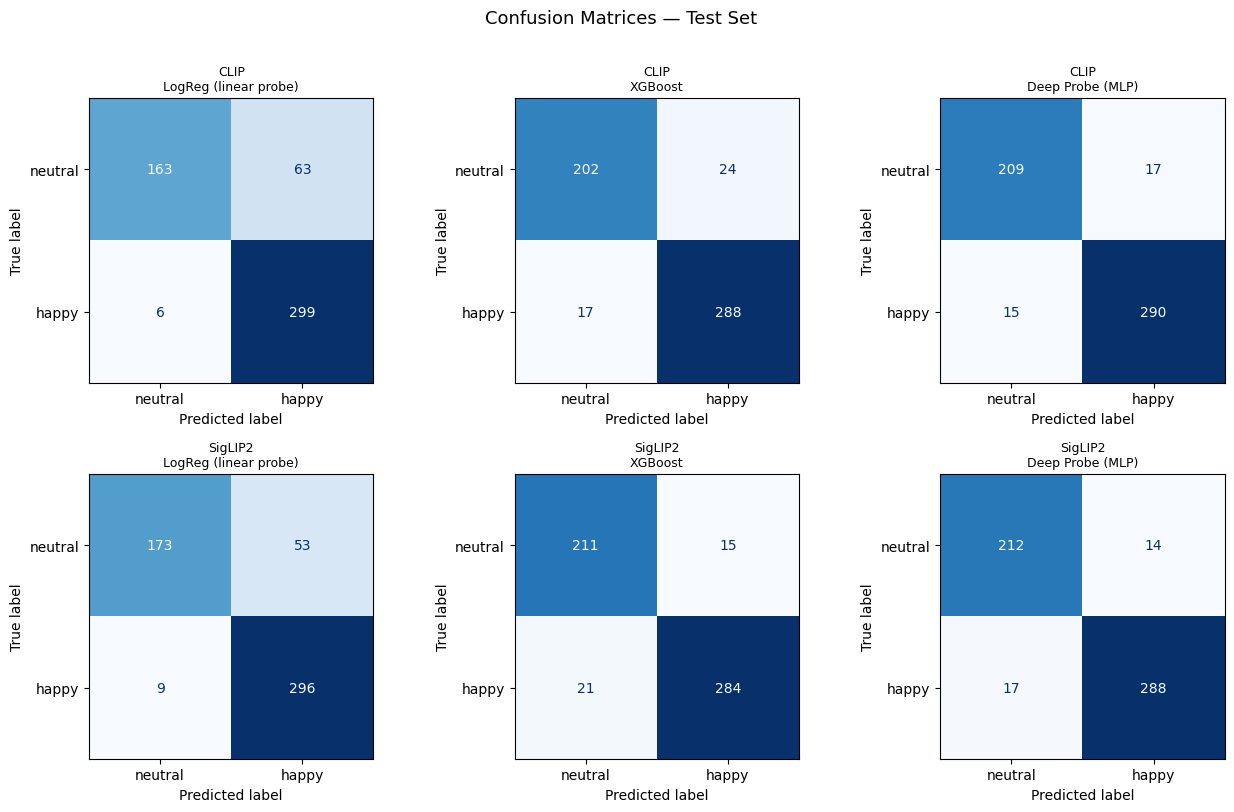

Saved: confusion_matrices.png


In [46]:
# Cell 11: Confusion matrices — 2 × 3 grid (embedding × classifier)

emb_names = list(embedding_sets.keys())   # ["CLIP", "SigLIP2"]
clf_names = list(classifiers.keys())      # 3 classifiers
label_names = ["neutral", "happy"]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for r, emb_name in enumerate(emb_names):
    for c, clf_name in enumerate(clf_names):
        key = f"{emb_name} + {clf_name}"
        clf_fit, X_te = trained_clfs[key]
        y_pred = clf_fit.predict(X_te)
        cm = confusion_matrix(y_test, y_pred)
        ax = axes[r, c]
        ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
            ax=ax, colorbar=False, cmap="Blues"
        )
        ax.set_title(f"{emb_name}\n{clf_name}", fontsize=9)
        if r == 1:
            ax.set_xlabel("Predicted label")
        if c == 0:
            ax.set_ylabel("True label")

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

Extracting CLIP embeddings for all combined images...
Extracting SigLIP2 embeddings for all combined images...
Computing t-SNE projections...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


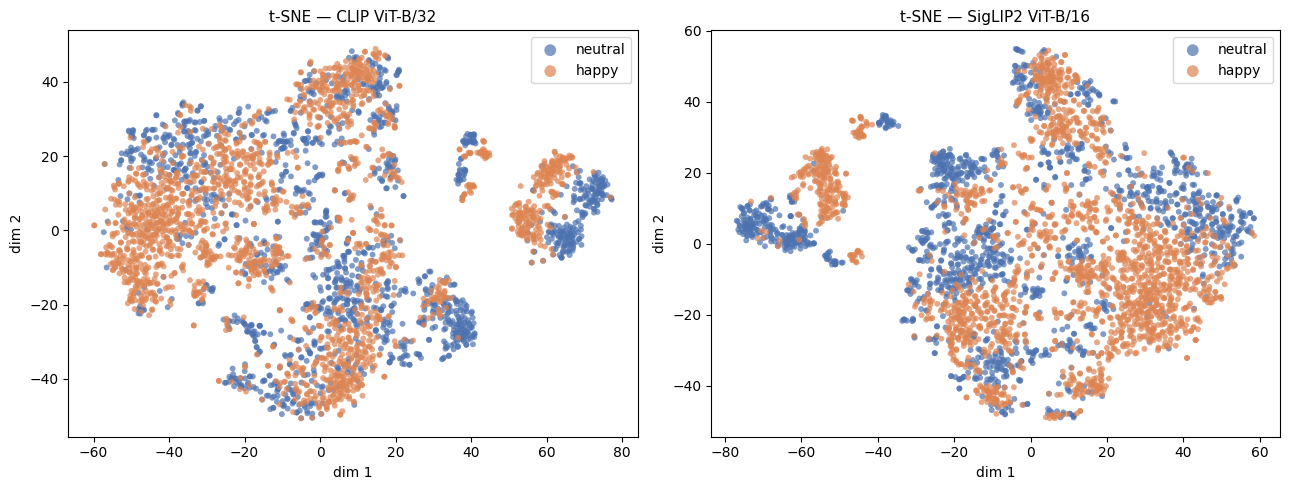

Saved: tsne_comparison.png


In [39]:
# Cell 12: t-SNE — side-by-side for CLIP and SigLIP2 (all combined images)

print("Extracting CLIP embeddings for all combined images...")
X_clip_all, y_all = extract_embeddings(combined_df, clip_processor, clip_model, "clip", DEVICE)

print("Extracting SigLIP2 embeddings for all combined images...")
X_sig_all, _ = extract_embeddings(combined_df, siglip_processor, siglip_model, "siglip", DEVICE)

print("Computing t-SNE projections...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED)
X_clip_tsne = tsne.fit_transform(X_clip_all)
X_sig_tsne  = tsne.fit_transform(X_sig_all)

COLORS = {0: "#4C72B0", 1: "#DD8452"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, X_2d, title in zip(
    axes,
    [X_clip_tsne, X_sig_tsne],
    ["CLIP ViT-B/32", "SigLIP2 ViT-B/16"],
):
    for label_idx, label_name in enumerate(["neutral", "happy"]):
        mask = y_all == label_idx
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=COLORS[label_idx], label=label_name,
            alpha=0.7, s=18, edgecolors="none",
        )
    ax.set_title(f"t-SNE — {title}", fontsize=11)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig("tsne_comparison.png", dpi=150)
plt.show()
print("Saved: tsne_comparison.png")

Computing UMAP projections...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


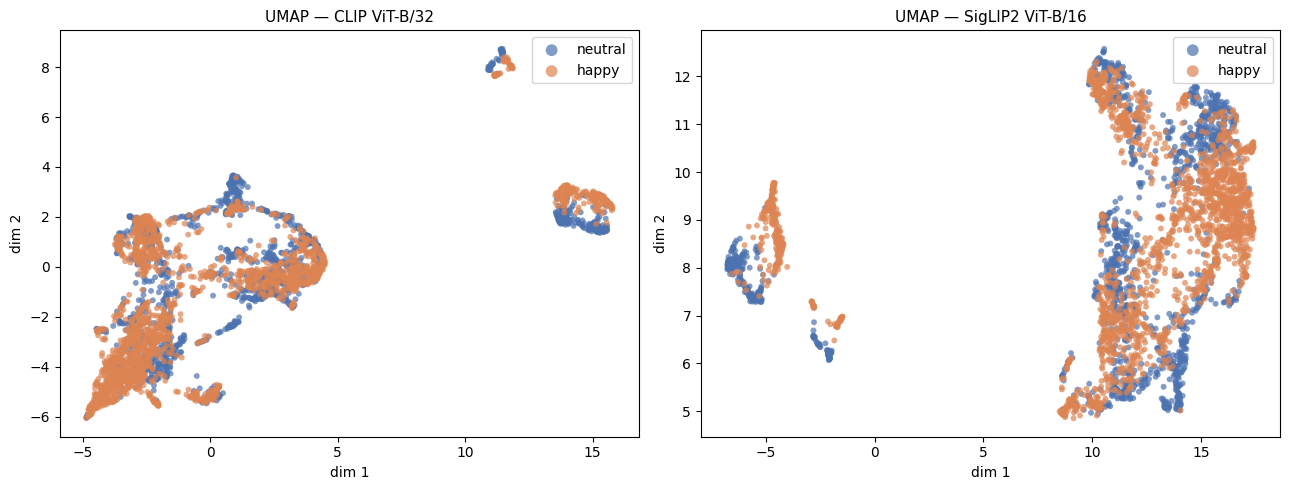

Saved: umap_comparison.png


In [40]:
# Cell 13: UMAP — side-by-side for CLIP and SigLIP2 (all 500 images)

print("Computing UMAP projections...")
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED)
X_clip_umap = reducer.fit_transform(X_clip_all)
X_sig_umap  = reducer.fit_transform(X_sig_all)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, X_2d, title in zip(
    axes,
    [X_clip_umap, X_sig_umap],
    ["CLIP ViT-B/32", "SigLIP2 ViT-B/16"],
):
    for label_idx, label_name in enumerate(["neutral", "happy"]):
        mask = y_all == label_idx
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=COLORS[label_idx], label=label_name,
            alpha=0.7, s=18, edgecolors="none",
        )
    ax.set_title(f"UMAP — {title}", fontsize=11)
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
    ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig("umap_comparison.png", dpi=150)
plt.show()
print("Saved: umap_comparison.png")

=== Best combination: SigLIP2 + Deep Probe (MLP) ===
              precision    recall  f1-score   support

     neutral       0.93      0.94      0.93       226
       happy       0.95      0.94      0.95       305

    accuracy                           0.94       531
   macro avg       0.94      0.94      0.94       531
weighted avg       0.94      0.94      0.94       531



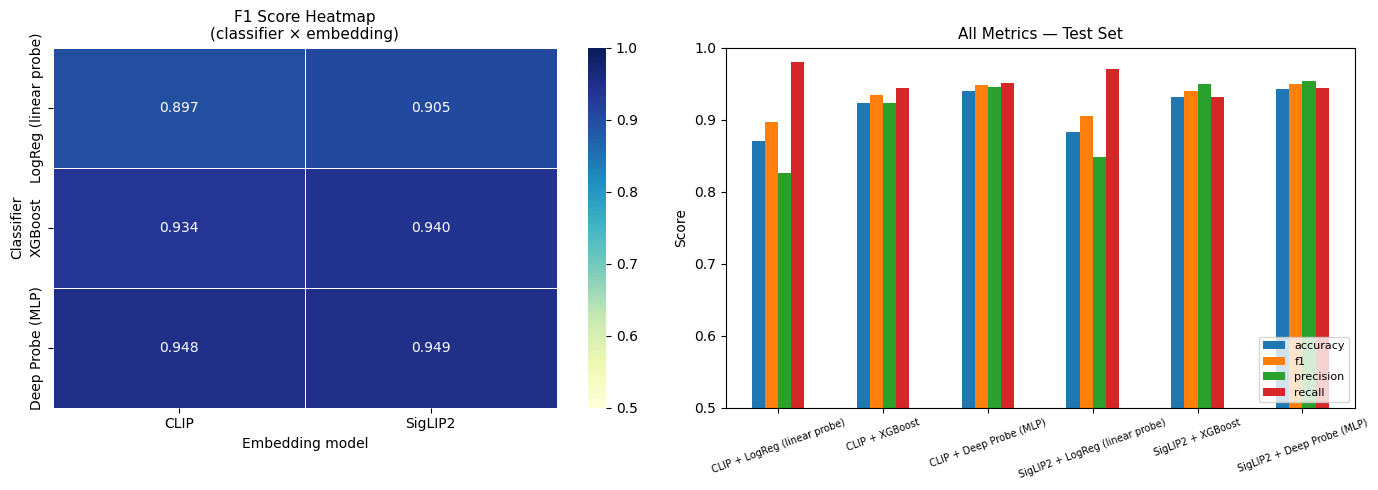

Saved: results_heatmap.png

Done.


In [41]:
# Cell 14: Final report — classification report, heatmap, bar chart

# ── Detailed classification report for best combination ──────────────────────
best_clf_fit, X_te_best = trained_clfs[best_key]
y_pred_best = best_clf_fit.predict(X_te_best)

print(f"=== Best combination: {best_key} ===")
print(classification_report(y_test, y_pred_best, target_names=["neutral", "happy"]))

# ── F1 heatmap: rows = classifiers, columns = embeddings ────────────────────
f1_matrix = pd.DataFrame(
    index=list(classifiers.keys()),
    columns=list(embedding_sets.keys()),
    dtype=float,
)
for emb_name in embedding_sets:
    for clf_name in classifiers:
        key = f"{emb_name} + {clf_name}"
        f1_matrix.loc[clf_name, emb_name] = results[key]["f1"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    f1_matrix.astype(float), annot=True, fmt=".3f",
    cmap="YlGnBu", vmin=0.5, vmax=1.0,
    ax=axes[0], linewidths=0.5,
)
axes[0].set_title("F1 Score Heatmap\n(classifier × embedding)", fontsize=11)
axes[0].set_xlabel("Embedding model")
axes[0].set_ylabel("Classifier")

# Bar chart — all 4 metrics for all 6 combinations
metrics = ["accuracy", "f1", "precision", "recall"]
res_plot = pd.DataFrame(results).T[metrics].astype(float)
res_plot.plot(kind="bar", ax=axes[1], ylim=(0.5, 1.0), rot=20)
axes[1].set_title("All Metrics — Test Set", fontsize=11)
axes[1].set_ylabel("Score")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.savefig("results_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results_heatmap.png")
print("\nDone.")

In [42]:
# Cell 15: Save best model to Google Drive
import pickle

MODEL_DIR = Path("/content/gdrive/MyDrive/AffectiveComputing/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_clf_fit, _ = trained_clfs[best_key]
model_artifact = {
    "model": best_clf_fit,
    "best_key": best_key,
    "label_map": LABEL_MAP,
}

safe_name = best_key.lower().replace(" + ", "__").replace(" ", "_").replace("(", "").replace(")", "")
model_path = MODEL_DIR / f"best_model_{safe_name}.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model_artifact, f)

print(f"Saved best model to: {model_path}")

Saved best model to: /content/gdrive/MyDrive/AffectiveComputing/models/best_model_siglip2__deep_probe_mlp.pkl


In [43]:
# Cell 16: Save CLIP and SigLIP2 models to Google Drive
HF_MODEL_DIR = Path("/content/gdrive/MyDrive/AffectiveComputing/hf_models")
HF_MODEL_DIR.mkdir(parents=True, exist_ok=True)

clip_export_dir = HF_MODEL_DIR / "clip-vit-base-patch32"
siglip_export_dir = HF_MODEL_DIR / "siglip2-base-patch16-224"

clip_model.save_pretrained(clip_export_dir)
clip_processor.save_pretrained(clip_export_dir)

siglip_model.save_pretrained(siglip_export_dir)
siglip_processor.save_pretrained(siglip_export_dir)

print(f"Saved CLIP model+processor to: {clip_export_dir}")
print(f"Saved SigLIP2 model+processor to: {siglip_export_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved CLIP model+processor to: /content/gdrive/MyDrive/AffectiveComputing/hf_models/clip-vit-base-patch32
Saved SigLIP2 model+processor to: /content/gdrive/MyDrive/AffectiveComputing/hf_models/siglip2-base-patch16-224


In [44]:
# Cell 17: Save embeddings to Google Drive
EMB_DIR = Path("/content/gdrive/MyDrive/AffectiveComputing/embeddings")
EMB_DIR.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    EMB_DIR / "clip_embeddings.npz",
    X_train=X_clip_train, X_val=X_clip_val, X_test=X_clip_test,
    y_train=y_train, y_test=y_test,
)

np.savez_compressed(
    EMB_DIR / "siglip2_embeddings.npz",
    X_train=X_sig_train, X_val=X_sig_val, X_test=X_sig_test,
    y_train=y_train, y_test=y_test,
)

print(f"Saved CLIP embeddings to: {EMB_DIR / 'clip_embeddings.npz'}")
print(f"Saved SigLIP2 embeddings to: {EMB_DIR / 'siglip2_embeddings.npz'}")

Saved CLIP embeddings to: /content/gdrive/MyDrive/AffectiveComputing/embeddings/clip_embeddings.npz
Saved SigLIP2 embeddings to: /content/gdrive/MyDrive/AffectiveComputing/embeddings/siglip2_embeddings.npz
